In [20]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from tqdm.auto import trange

from src.helpers import (letter_subplots, 
                         gini)
from src.SlovotvirModel import (run_model_parallel)

sns.set(context='paper', 
        style='ticks',
        font_scale=1.2, 
        palette='colorblind',
        # font='serif',
        )

In [21]:
def prepare_data(epochs: int):
    df = pd.read_csv('../data/words_translations.csv')
    df = (df.
          pipe(lambda df: df[~df['rating'].isna()]). # rating is not null
          pipe(lambda df: df[df['rating'] >= 0]). # rating is higher or equal to 0
          pipe(lambda df: df.assign(translation_created_at=pd.to_datetime(df['translation_created_at']))). # assign translation creation time
          pipe(lambda df: df.assign(word_created_at=pd.to_datetime(df['word_created_at']))). # assign word creation time
          pipe(lambda df: df.assign(bin=pd.cut(df['translation_created_at'], bins=epochs, labels=range(epochs)))). # cut into bins
          pipe(lambda df: df[~df['bin'].isna()]).
          pipe(lambda df: df.assign(word_n_words=df['word_body'].str.split().str.len())).
          pipe(lambda df: df[df['word_n_words'] == 1]).
          pipe(lambda df: df.assign(translation_n_words=df['translation_body'].str.split().str.len())).
          pipe(lambda df: df[df['translation_n_words'] == 1]).
          pipe(lambda df: df.assign(translation_len=df['translation_body'].str.len())).
          pipe(lambda df: df.assign(word_len=df['word_body'].str.len())).
          pipe(lambda df: df[df['translation_len'] > 1]).
          pipe(lambda df: df[df['word_len'] > 1])
    ).dropna()

    # Votes
    votes = pd.read_csv("../data/votes.csv")
    votes['created_at'] = pd.to_datetime(votes['created_at'])
    votes['bin'] = pd.cut(votes['created_at'], bins=pd.date_range(start=df['translation_created_at'].min(),
                                                                  end=df['translation_created_at'].max(),
                                                                  periods=epochs+1), labels=range(epochs))
    votes = votes[~votes['bin'].isna()]

    # Keep only votes for translations in df
    votes = votes[votes['translation_id'].isin(df['translation_id'])]
    votes_ = votes.groupby(['bin', 'user_id']).size().reset_index(name='votes')
    votes_ = votes_.query('votes > 0')
    votes_ = votes_.groupby('bin')['votes'].apply(list).reset_index(name='votes')

    # Unique words per bin
    seen_word_ids = set()
    df['truly_unique_words'] = 0
    for bin_name in sorted(df['bin'].unique()):
        current_bin = df[df['bin'] == bin_name]
        new_unique_words = set(current_bin['word_id']) - seen_word_ids
        seen_word_ids.update(new_unique_words)
        df.loc[df['bin'] == bin_name, 'truly_unique_words'] = len(new_unique_words)

    df_unique = df.groupby('bin').agg({
        'truly_unique_words': 'max',
        'translation_id': 'nunique'
    }).reset_index()
    df_unique.columns = ['bin', 'n_words', 'n_translations']

    # Final outputs — sum votes per bin to get a single int per epoch
    votes_dict = votes_.set_index('bin')['votes'].to_dict()
    votes_ = np.array([sum(v) for v in votes_dict.values()])
    n_words = df_unique['n_words'].to_numpy().round().astype(int)
    n_translations = df_unique['n_translations'].to_numpy().astype(int)
    translation_len = df['translation_len'].to_numpy().astype(int)

    return votes_, n_words, n_translations, translation_len

In [35]:
votes_, n_words, n_translations, translation_len = prepare_data(epochs=10)

In [ ]:
N = 10 # Number of bins

alpha = np.linspace(-5, 5, N) # length
beta = np.linspace(-5, 5, N) # frequency

In [37]:
gini_m = np.zeros((N, N))
len_m = np.zeros((N, N))

for i in trange(N):
    for j in range(N):
        run = run_model_parallel([alpha[i]] * 1, [beta[j]] * 1, [1] * 1, 1)
        gini_m[i, j] = gini(run[0][0])
        # len_m[i, j] = np.mean([i * j for i, j in run[0][1]])
        len_m[i, j] = sum(run[0][1]) / sum(run[0][0])

  0%|          | 0/10 [00:00<?, ?it/s]

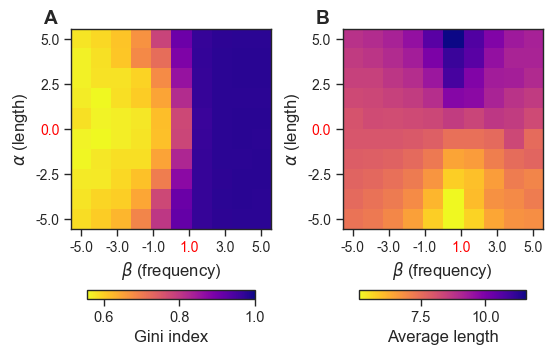

In [39]:
# only plot the gini index (alpha and beta) and mean length (alpha and beta)

fig, axes = plt.subplots(1, 2, figsize=(6.2, 4))

letter_subplots(axes, yoffset=1.05)

# Plot 1: gini_m
im1 = axes[0].imshow(gini_m, cmap='plasma_r', 
                     interpolation='none', vmax=1)
axes[0].invert_yaxis()
axes[0].set_xlabel(r'$\beta$ (frequency)', fontsize=12)
axes[0].set_ylabel(r'$\alpha$ (length)', fontsize=12)
axes[0].set_xticks(np.linspace(0, N - 1, 6))
axes[0].set_xticklabels(np.round(np.linspace(-5, 5, 6), 2))
axes[0].xaxis.get_ticklabels()[3].set_color('red')
axes[0].set_yticks(np.linspace(0, N - 1, 5))
axes[0].set_yticklabels(np.round(np.linspace(-5, 5, 5), 2))
axes[0].yaxis.get_ticklabels()[2].set_color('red')
cbar1 = fig.colorbar(im1, ax=axes[0], location='bottom', 
                     shrink=0.8, pad=0.2)
cbar1.set_label('Gini index', fontsize=12)

# Plot 2: len_m
im4 = axes[1].imshow(len_m, cmap='plasma_r', interpolation='none',
                     vmax=max(len_m.flatten()))
axes[1].invert_yaxis()
axes[1].set_xlabel(r'$\beta$ (frequency)', fontsize=12)
axes[1].set_ylabel(r'$\alpha$ (length)', fontsize=12)
axes[1].set_xticks(np.linspace(0, N - 1, 6))
axes[1].set_xticklabels(np.round(np.linspace(-5, 5, 6), 2))
# color 1 ticks in red on x-axis
axes[1].xaxis.get_ticklabels()[3].set_color('red')
axes[1].set_yticks(np.linspace(0, N - 1, 5))
axes[1].set_yticklabels(np.round(np.linspace(-5, 5, 5), 2))
# color 0 ticks in red on y-axis
axes[1].yaxis.get_ticklabels()[2].set_color('red')
cbar2 = fig.colorbar(im4, ax=axes[1], location='bottom', 
                     shrink=0.8, pad=0.2)
cbar2.set_label('Average length', fontsize=12)

# increase font size in the plot
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.tick_params(axis='both', which='minor', labelsize=10)

# add a title on top of the figure
# fig.suptitle(r'$\tau$ = 1', 
#              fontsize=12, fontweight='bold',
#              x=0.1,
#              y=0.94)
# reduce gap between subplots
plt.subplots_adjust(wspace=0.3)

# reduce image size by rasterizing
for ax in axes:
    ax.get_images()[0].set_rasterized(True)

# plt.savefig('../figures/Figure_3.pdf',
#             dpi=300, 
#             bbox_inches='tight',)
# plt.tight_layout()
plt.show()